<a href="https://colab.research.google.com/github/anuragsingh7058/exoplanet-detection/blob/main/exoplanet_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
 import pandas as pd

train_df = pd.read_csv("exoTrain.txt")
test_df = pd.read_csv("exoTest.txt")

print(train_df.shape)
print(train_df['LABEL'].value_counts())

(3696, 3198)
LABEL
1    3659
2      37
Name: count, dtype: int64


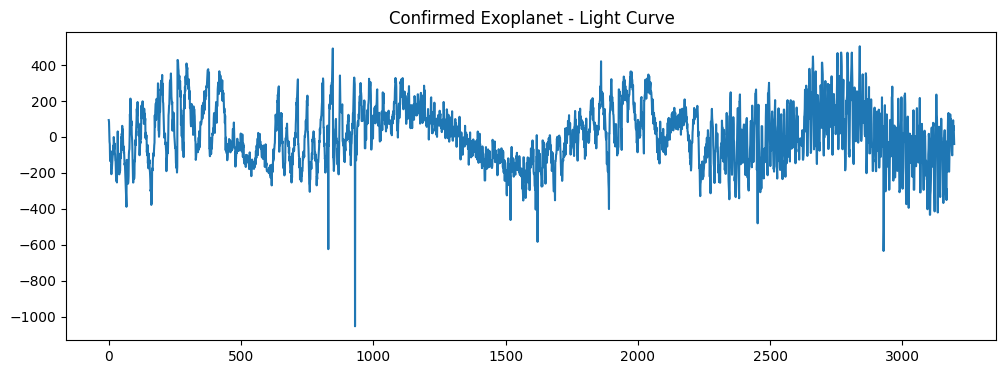

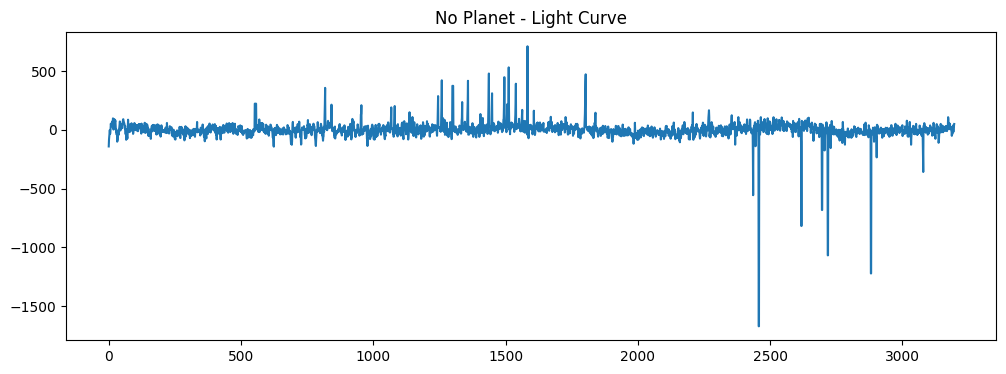

In [7]:
import matplotlib.pyplot as plt

planet_row = train_df[train_df['LABEL']==2].iloc[0, 1:]
no_planet_row = train_df[train_df['LABEL']==1].iloc[0, 1:]

plt.figure(figsize=(12,4))
plt.plot(planet_row.values)
plt.title("Confirmed Exoplanet - Light Curve")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(no_planet_row.values)
plt.title("No Planet - Light Curve")
plt.show()

In [8]:
import numpy as np

def normalize(df):
    flux = df.iloc[:, 1:].values
    flux = (flux - np.mean(flux, axis=1).reshape(-1,1)) / np.std(flux, axis=1).reshape(-1,1)
    return flux

X_train = normalize(train_df)
y_train = train_df['LABEL'].values
X_test = normalize(test_df)
y_test = test_df['LABEL'].values

print(X_train.shape, y_train.shape)

(3696, 3197) (3696,)


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

# reshape data for CNN (needs 3D shape: samples, timesteps, channels)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# convert labels from 1/2 to 0/1 (model expects 0-indexed classes)
y_train_cnn = y_train - 1
y_test_cnn = y_test - 1

model = models.Sequential([
    layers.Conv1D(16, kernel_size=5, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=4),
    layers.Conv1D(32, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(pool_size=4),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3193, 16)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 798, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 794, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 198, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6336)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       202,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,505 (802.75 KB)

 Trainable params: 205,505 (802.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from sklearn.utils import class_weight
import numpy as np

# handle class imbalance (37 planets vs 2222 non-planets)
weights = class_weight.compute_class_weight('balanced',
           classes=np.unique(y_train_cnn),
           y=y_train_cnn)
class_weights = dict(enumerate(weights))

history = model.fit(
    X_train_cnn, y_train_cnn,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.6922 - loss: 0.6880 - val_accuracy: 0.8878 - val_loss: nan
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.8931 - loss: 0.2272 - val_accuracy: 0.8473 - val_loss: nan
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9496 - loss: 0.1044 - val_accuracy: 0.9486 - val_loss: nan
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9756 - loss: 0.0529 - val_accuracy: 0.9811 - val_loss: nan
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9811 - loss: 0.0367 - val_accuracy: 0.9851 - val_loss: nan
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9895 - loss: 0.0241 - val_accuracy: 0.9865 - val_loss: nan
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9939 - loss: 0.0181 - val_accuracy: 0.9838 - val_loss: nan
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9915 - loss: 0.0151 - val_accuracy: 0.9919 - val_loss: nan
Epoch 

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


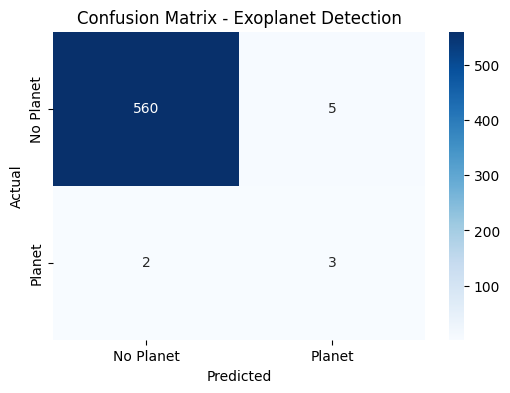

              precision    recall  f1-score   support

   No Planet       1.00      0.99      0.99       565
      Planet       0.38      0.60      0.46         5

    accuracy                           0.99       570
   macro avg       0.69      0.80      0.73       570
weighted avg       0.99      0.99      0.99       570



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# run model on test data it has never seen
y_pred_prob = model.predict(X_test_cnn)

# convert probabilities to 0 or 1 (planet or not)
# anything above 0.5 = planet detected
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# confusion matrix shows us WHERE the model is right and wrong
cm = confusion_matrix(y_test_cnn, y_pred)

# visualize it as a heatmap so it's easy to read
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Planet', 'Planet'],
            yticklabels=['No Planet', 'Planet'])
plt.title("Confusion Matrix - Exoplanet Detection")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# detailed breakdown of precision, recall, f1
print(classification_report(y_test_cnn, y_pred, target_names=['No Planet', 'Planet']))

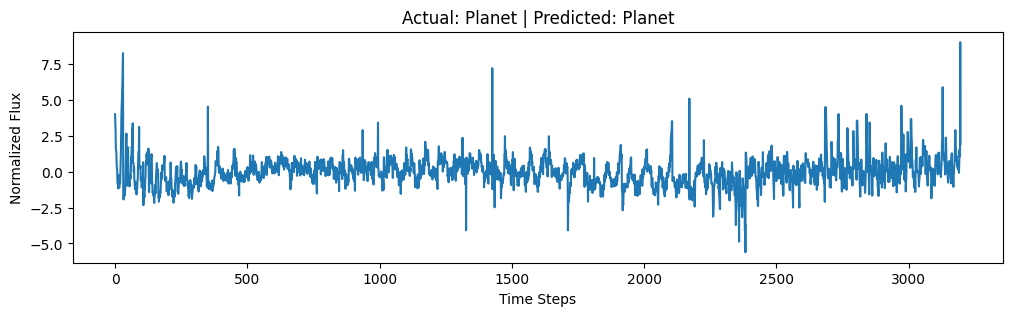

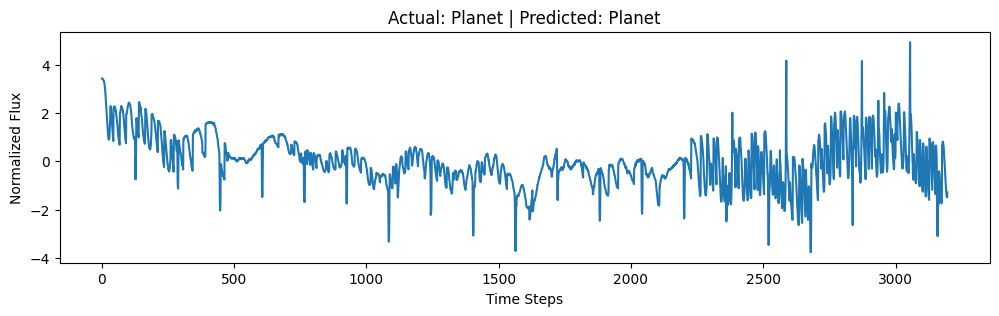

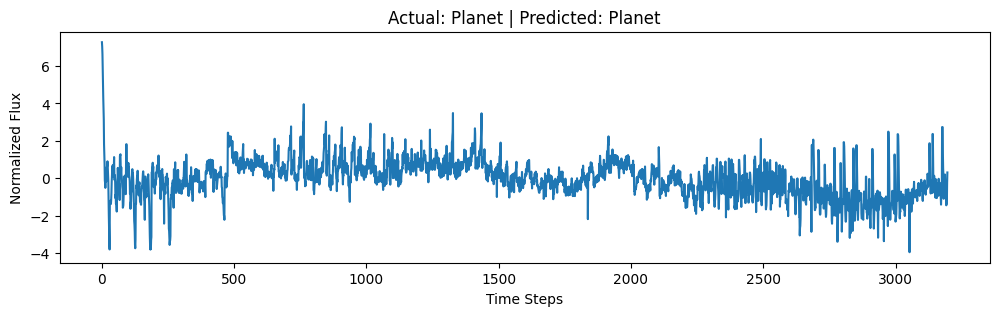

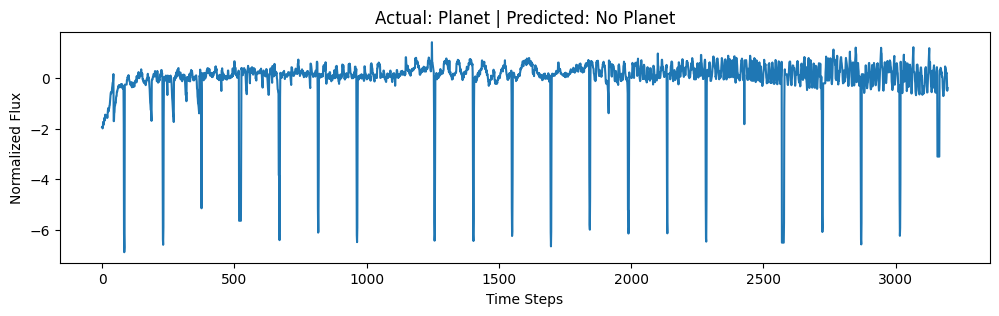

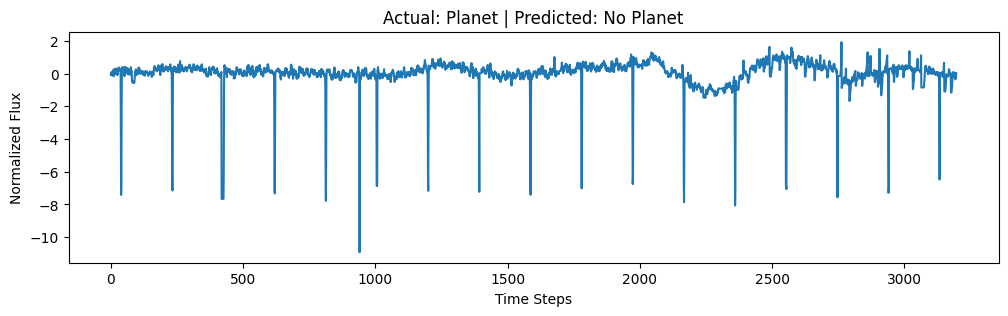

In [13]:
# find which test stars were actual planets
planet_indices = np.where(y_test_cnn == 1)[0]

# plot each one with model's prediction label
for i in planet_indices:
    actual = "Planet" if y_test_cnn[i] == 1 else "No Planet"
    predicted = "Planet" if y_pred[i] == 1 else "No Planet"

    plt.figure(figsize=(12, 3))
    plt.plot(X_test_cnn[i].flatten())
    plt.title(f"Actual: {actual} | Predicted: {predicted}")
    plt.xlabel("Time Steps")
    plt.ylabel("Normalized Flux")
    plt.show()

In [14]:
# SMOTE creates synthetic planet examples to balance the dataset
# so model sees equal amounts of planet and no-planet during training
from imblearn.over_sampling import SMOTE

# flatten to 2D for SMOTE (it doesn't work with 3D CNN format)
X_flat = X_train.reshape(X_train.shape[0], -1)

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_flat, y_train_cnn)

print(f"Before SMOTE: {np.bincount(y_train_cnn)}")
print(f"After SMOTE: {np.bincount(y_resampled)}")

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [15]:
# some stars have missing brightness readings (NaN) - fill them with 0
# SMOTE can't handle missing values so we clean first
X_train_clean = np.nan_to_num(X_train, nan=0.0)

# flatten to 2D for SMOTE
X_flat = X_train_clean.reshape(X_train_clean.shape[0], -1)

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_flat, y_train_cnn)

print(f"Before SMOTE: {np.bincount(y_train_cnn)}")
print(f"After SMOTE: {np.bincount(y_resampled)}")

Before SMOTE: [3659   37]
After SMOTE: [3659 3659]


In [16]:
# reshape back to 3D for CNN
X_resampled_cnn = X_resampled.reshape(X_resampled.shape[0], X_resampled.shape[1], 1)

# build a fresh model (don't reuse the old one trained on imbalanced data)
model2 = models.Sequential([
    layers.Conv1D(16, kernel_size=5, activation='relu', input_shape=(X_resampled_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=4),
    layers.Conv1D(32, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(pool_size=4),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train on balanced SMOTE data — no class_weight needed anymore since data is already balanced
history2 = model2.fit(
    X_resampled_cnn, y_resampled,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.9667 - loss: 0.0975 - val_accuracy: 1.0000 - val_loss: 0.0098
Epoch 2/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9966 - loss: 0.0143 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 3/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.9988 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 4/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - accuracy: 0.9990 - loss: 0.0049 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 5/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.9993 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 6/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 2.6493e-04
Epoch 7/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 1.0000 - loss: 9.0326e-04 - val_accuracy: 1.0000 - val_loss: 2.0032e-04
Epoch 8/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.9998 - los

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


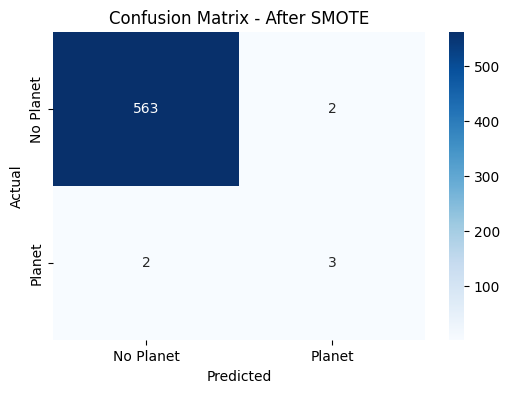

              precision    recall  f1-score   support

   No Planet       1.00      1.00      1.00       565
      Planet       0.60      0.60      0.60         5

    accuracy                           0.99       570
   macro avg       0.80      0.80      0.80       570
weighted avg       0.99      0.99      0.99       570



In [17]:
# test model2 on real unseen test data
X_test_clean = np.nan_to_num(X_test, nan=0.0)
X_test_cnn2 = X_test_clean.reshape(X_test_clean.shape[0], X_test_clean.shape[1], 1)

y_pred2_prob = model2.predict(X_test_cnn2)
y_pred2 = (y_pred2_prob > 0.5).astype(int).flatten()

cm2 = confusion_matrix(y_test_cnn, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Planet', 'Planet'],
            yticklabels=['No Planet', 'Planet'])
plt.title("Confusion Matrix - After SMOTE")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_test_cnn, y_pred2, target_names=['No Planet', 'Planet']))

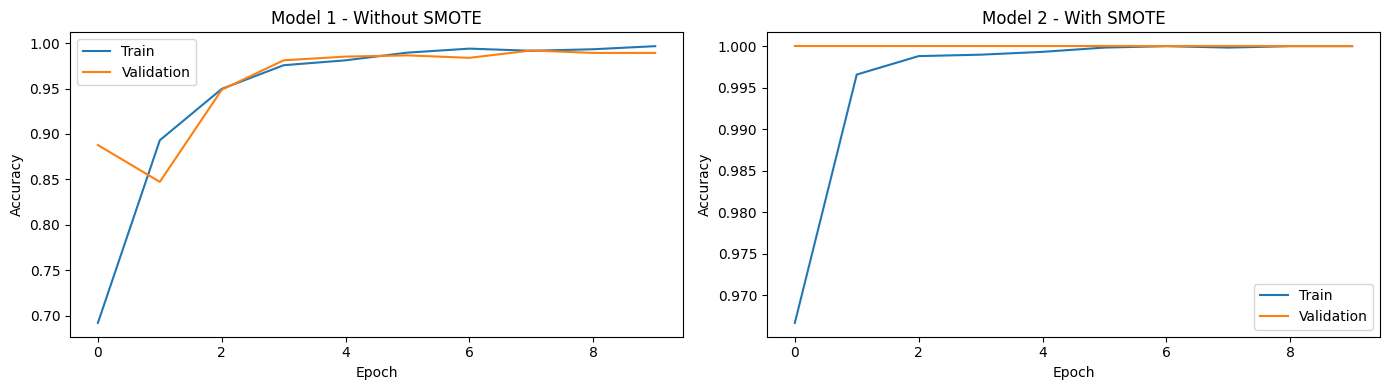

In [18]:
# side by side comparison of model1 vs model2 training
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# model 1 - without SMOTE
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model 1 - Without SMOTE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# model 2 - with SMOTE
axes[1].plot(history2.history['accuracy'], label='Train')
axes[1].plot(history2.history['val_accuracy'], label='Validation')
axes[1].set_title('Model 2 - With SMOTE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()